In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import time
import numpy as np
import cv2
import seaborn as sns
import keras
import keras_tuner as kt

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import applications, models, layers, Sequential
from keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
TRAIN_DATA_PATH = "../affectnet_dataset/Train"
TEST_DATA_PATH = "../affectnet_dataset/Test"
EPOCHS = 100
RANDOM_SEED = 40
BATCH_SIZE = 32
IMG_SIZE = (96,96)

SAVED_MODEL = "../saved_models/transfer_kt_model.keras"


In [3]:
# flow_from_directory is older approach - slower
train_dataset = image_dataset_from_directory(
    TRAIN_DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed = RANDOM_SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode = "int"
)

val_dataset = image_dataset_from_directory(
    TRAIN_DATA_PATH,
    validation_split=0.2,
    seed = RANDOM_SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode = "int",
    subset="validation"
)

test_dataset = image_dataset_from_directory(
    TEST_DATA_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode = "int"
)

Found 16108 files belonging to 8 classes.
Using 12887 files for training.
Found 16108 files belonging to 8 classes.
Using 3221 files for validation.
Found 14518 files belonging to 8 classes.


In [4]:
train_counts = {}
CLASSES = train_dataset.class_names
num_classes = len(CLASSES)

for cls in CLASSES:
    cls_folder = os.path.join(TRAIN_DATA_PATH, cls)
    train_counts[cls] = len(os.listdir(cls_folder))

print(train_counts)

{'anger': 1500, 'contempt': 1559, 'disgust': 1229, 'fear': 1512, 'happy': 2340, 'neutral': 2758, 'sad': 3091, 'surprise': 2119}


In [5]:
print(train_dataset.class_names)

['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [6]:
'''
Calculate class weights for imbalanced dataset
Create label list manually from folder counts
Class weights змушують loss сильніше штрафувати помилки на rare classes.
'''
train_label_ids = []
for idx, cls in enumerate(CLASSES):
    count = train_counts[cls]
    train_label_ids.extend([idx] * count)

train_label_ids = np.array(train_label_ids)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_label_ids),
    y=train_label_ids
)

class_weights = dict(zip(range(num_classes), class_weights_array))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.3423333333333334), 1: np.float64(1.2915330339961513), 2: np.float64(1.6383238405207485), 3: np.float64(1.3316798941798942), 4: np.float64(0.8604700854700855), 5: np.float64(0.7300580130529369), 6: np.float64(0.6514073115496603), 7: np.float64(0.9502123643227938)}


In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05), # 0.1
    layers.RandomZoom(0.05),
], name="data_augmentation")

In [8]:
base_model = applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False, # rm last classification block
    weights = "imagenet" # take weights pretrained on imagenet
)
# Freeze base block
base_model.trainable = False

In [9]:
num_classes = len(CLASSES)

In [10]:
def build_model(hp):
    inputs = layers.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        kernel_regularizer=tf.keras.regularizers.l2(
            hp.Float('l2_1', 1e-5, 1e-4, sampling='log')
        )
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(hp.Float('dropout1', 0.1, 0.4, step=0.1))(x)

    x = layers.Dense(
        64,
        kernel_regularizer=tf.keras.regularizers.l2(
            hp.Float('l2_2', 1e-5, 1e-4, sampling='log')
        )
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(hp.Float('dropout2', 0.1, 0.4, step=0.1))(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=AdamW(
            learning_rate=hp.Float('lr', 1e-5, 1e-3, sampling='log')
        ),
        metrics=['accuracy']
    )
    return model

In [11]:
'''
Initialize a tuner (here, HyperBand). 
We use objective to specify the objective to select the best models,
and we use max_trials to specify the number of different models to try.
'''
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3, # Reduction factor 3x fewer models in the next round
    directory='keras_tuner_results',
    project_name='emotion_recognition',
    overwrite=True
)

In [12]:
tuner.search_space_summary()

Search space summary
Default search space size: 5
l2_1 (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.0001, 'step': None, 'sampling': 'log'}
dropout1 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
l2_2 (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.0001, 'step': None, 'sampling': 'log'}
dropout2 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
lr (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.001, 'step': None, 'sampling': 'log'}


In [13]:
tuner.search(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    class_weight=class_weights
)

Trial 30 Complete [00h 12m 24s]
val_accuracy: 0.28810927271842957

Best val_accuracy So Far: 0.4063955247402191
Total elapsed time: 02h 02m 08s


In [14]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hp)
best_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,431,496 (9.28 MB)

 Trainable params: 173,128 (676.28 KB)

 Non-trainable params: 2,258,368 (8.61 MB)

In [15]:
best_hp.values

{'l2_1': 1.0118631389888083e-05,
 'dropout1': 0.1,
 'l2_2': 5.353199386462578e-05,
 'dropout2': 0.2,
 'lr': 0.0004581466994406442,
 'tuner/epochs': 20,
 'tuner/initial_epoch': 7,
 'tuner/bracket': 1,
 'tuner/round': 1,
 'tuner/trial_id': '0023'}

In [16]:
tuner.results_summary()

Results summary
Results in keras_tuner_results\emotion_recognition
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0024 summary
Hyperparameters:
l2_1: 1.0118631389888083e-05
dropout1: 0.1
l2_2: 5.353199386462578e-05
dropout2: 0.2
lr: 0.0004581466994406442
tuner/epochs: 20
tuner/initial_epoch: 7
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0023
Score: 0.4063955247402191

Trial 0016 summary
Hyperparameters:
l2_1: 1.2485419367126874e-05
dropout1: 0.1
l2_2: 5.1487845877804396e-05
dropout2: 0.30000000000000004
lr: 0.0009065729012187748
tuner/epochs: 20
tuner/initial_epoch: 7
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0012
Score: 0.4029804468154907

Trial 0025 summary
Hyperparameters:
l2_1: 5.195158519999008e-05
dropout1: 0.4
l2_2: 5.812948219172319e-05
dropout2: 0.1
lr: 0.00028612572125398967
tuner/epochs: 20
tuner/initial_epoch: 7
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0018
Score: 0.3930456340312958

Trial 0017 summary
Hyperparameters:
l2_1: 1

In [17]:
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# es monitored val_loss
mc = ModelCheckpoint(SAVED_MODEL, monitor='val_loss', save_best_only=True)
csv_logger = CSVLogger('cnn_weighted_loss_training_log.csv')
rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3, # 0.5
    patience=2,  #3  
    min_lr=1e-6
)

In [18]:
# STAGE 1 - training frozen backbone
start = time.time()
history_stage1 = best_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    class_weight=class_weights,
    callbacks=[es, mc, csv_logger, rlr]
)
end = time.time()
elapsed_time = end - start

print("Stage 1 Training time: ", time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))

Epoch 1/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 38s 88ms/step - accuracy: 0.3144 - loss: 1.7668 - val_accuracy: 0.2943 - val_loss: 2.0378 - learning_rate: 4.5815e-04
Epoch 2/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 84ms/step - accuracy: 0.3853 - loss: 1.5388 - val_accuracy: 0.3207 - val_loss: 1.9467 - learning_rate: 4.5815e-04
Epoch 3/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 84ms/step - accuracy: 0.4177 - loss: 1.4679 - val_accuracy: 0.3437 - val_loss: 1.7511 - learning_rate: 4.5815e-04
Epoch 4/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.4417 - loss: 1.4237 - val_accuracy: 0.3533 - val_loss: 1.7121 - learning_rate: 4.5815e-04
Epoch 5/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 35s 86ms/step - accuracy: 0.4567 - loss: 1.3929 - val_accuracy: 0.3552 - val_loss: 1.7431 - learning_rate: 4.5815e-04
Epoch 6/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 35s 88ms/step - accuracy: 0.4654 - loss: 1.3633 - val_accuracy: 0.3558 - val_loss: 1.7573 - learning_rate: 4.5815e-04
Epoch 7/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 35s 88ms/ste

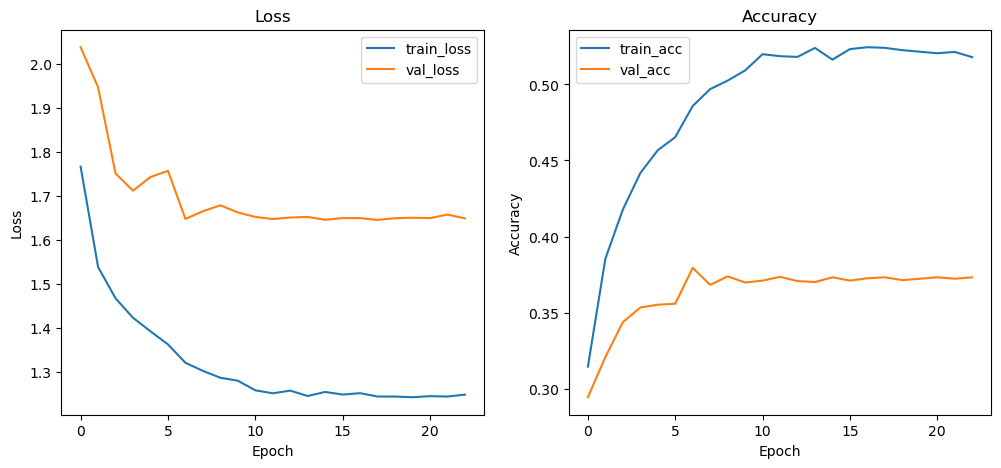

In [19]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_stage1.history['loss'], label='train_loss')
plt.plot(history_stage1.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_stage1.history['accuracy'], label='train_acc')
plt.plot(history_stage1.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [20]:
# STAGE 2
# Last 30 layers of base model fine-tuned
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

best_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=AdamW(learning_rate=1e-5, weight_decay=1e-5),
    metrics=['accuracy']
)

In [21]:
start = time.time()
history_stage2 = best_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=70,
    class_weight=class_weights,
    callbacks=[es, mc, csv_logger, rlr]
)
end = time.time()
print("Stage 2 training time:", time.strftime("%H:%M:%S", time.gmtime(end - start)))

Epoch 1/70
403/403 ━━━━━━━━━━━━━━━━━━━━ 48s 107ms/step - accuracy: 0.3670 - loss: 1.7145 - val_accuracy: 0.4170 - val_loss: 1.4652 - learning_rate: 1.0000e-05
Epoch 2/70
403/403 ━━━━━━━━━━━━━━━━━━━━ 39s 97ms/step - accuracy: 0.4031 - loss: 1.5353 - val_accuracy: 0.4098 - val_loss: 1.5012 - learning_rate: 1.0000e-05
Epoch 3/70
403/403 ━━━━━━━━━━━━━━━━━━━━ 39s 97ms/step - accuracy: 0.4282 - loss: 1.4649 - val_accuracy: 0.4079 - val_loss: 1.5087 - learning_rate: 1.0000e-05
Epoch 4/70
403/403 ━━━━━━━━━━━━━━━━━━━━ 39s 97ms/step - accuracy: 0.4415 - loss: 1.4315 - val_accuracy: 0.4033 - val_loss: 1.5053 - learning_rate: 3.0000e-06
Epoch 5/70
403/403 ━━━━━━━━━━━━━━━━━━━━ 38s 95ms/step - accuracy: 0.4416 - loss: 1.4270 - val_accuracy: 0.4039 - val_loss: 1.5068 - learning_rate: 3.0000e-06
Epoch 6/70
403/403 ━━━━━━━━━━━━━━━━━━━━ 38s 95ms/step - accuracy: 0.4437 - loss: 1.4095 - val_accuracy: 0.3980 - val_loss: 1.5073 - learning_rate: 1.0000e-06
Stage 2 training time: 00:04:01


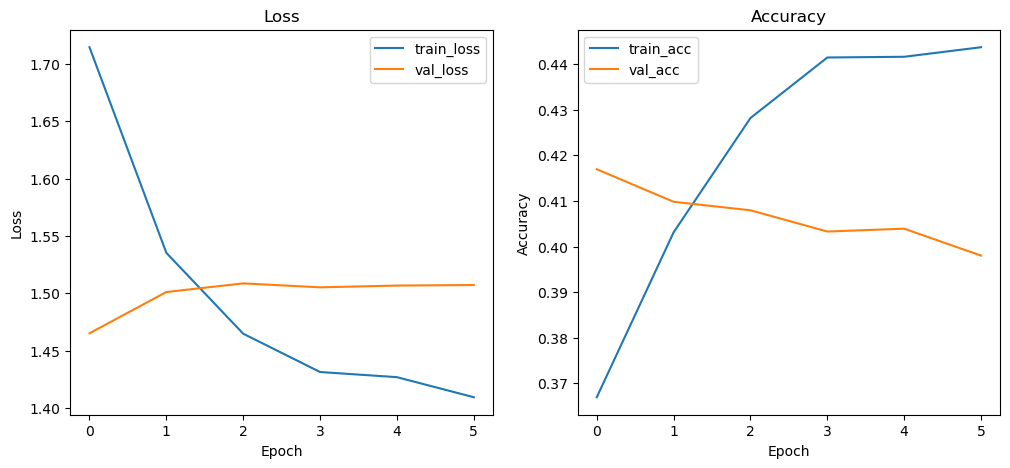

In [22]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_stage2.history['loss'], label='train_loss')
plt.plot(history_stage2.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_stage2.history['accuracy'], label='train_acc')
plt.plot(history_stage2.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [23]:
model = tf.keras.models.load_model(SAVED_MODEL)

In [24]:
test_loss, test_acc = best_model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc*100:.2f}%")

454/454 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.4260 - loss: 1.7493
Test Accuracy: 42.60%


Evaluating on Test Set...
454/454 ━━━━━━━━━━━━━━━━━━━━ 27s 56ms/step - accuracy: 0.4260 - loss: 1.7493
Test Accuracy: 42.60%
Generating predictions...
454/454 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step
14518
14518

Classification Report:

              precision    recall  f1-score   support

       anger       0.39      0.20      0.26      1718
    contempt       0.29      0.58      0.39      1312
     disgust       0.22      0.40      0.28      1248
        fear       0.50      0.22      0.30      1664
       happy       0.63      0.71      0.67      2704
     neutral       0.54      0.67      0.60      2368
         sad       0.35      0.23      0.28      1584
    surprise       0.36      0.19      0.25      1920

    accuracy                           0.43     14518
   macro avg       0.41      0.40      0.38     14518
weighted avg       0.44      0.43      0.41     14518



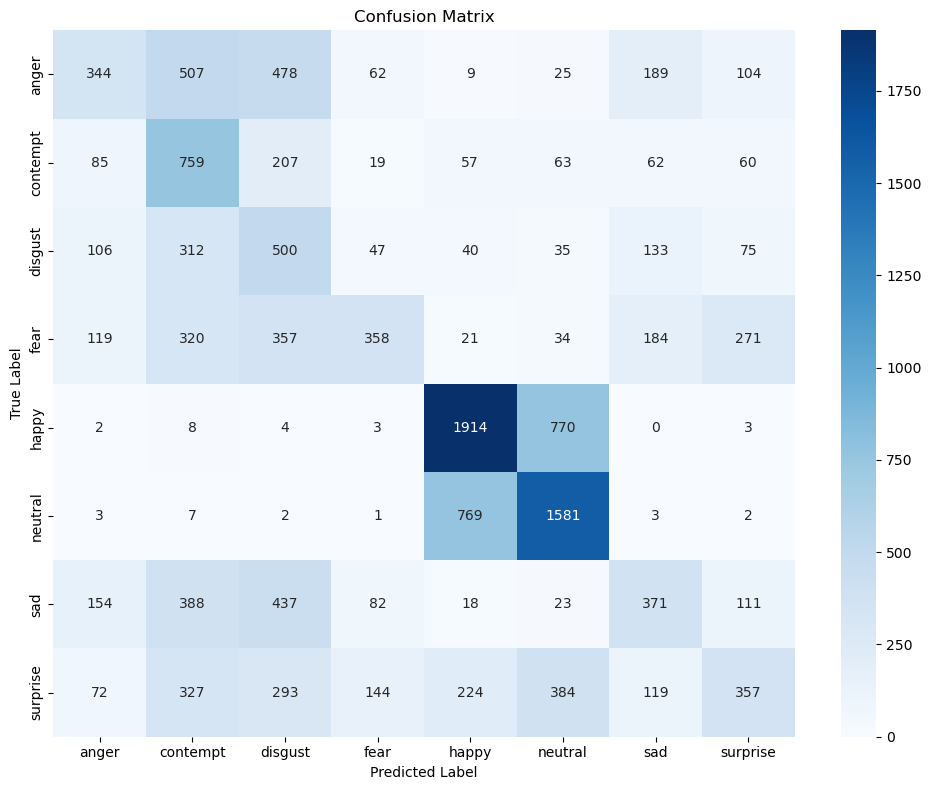

In [25]:
print("Evaluating on Test Set...")

loss, accuracy = model.evaluate(test_dataset)

print(f"Test Accuracy: {accuracy*100:.2f}%")

print("Generating predictions...")

predictions = model.predict(test_dataset, verbose=1)

# Predicted classes
y_pred_indices = np.argmax(predictions, axis=1)

# True labels
y_true_indices = np.concatenate([
    y.numpy() for x, y in test_dataset
])

# Class names
class_labels = CLASSES

print(len(y_true_indices))
print(len(y_pred_indices))

print("\nClassification Report:\n")

ls = list(range(len(CLASSES)))

eval_labels = list(range(num_classes))

print(classification_report(
    y_true_indices,
    y_pred_indices,
    labels=eval_labels,
    target_names=CLASSES,
    zero_division=0
))

cm = confusion_matrix(y_true_indices, y_pred_indices, labels=eval_labels)
# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.show()

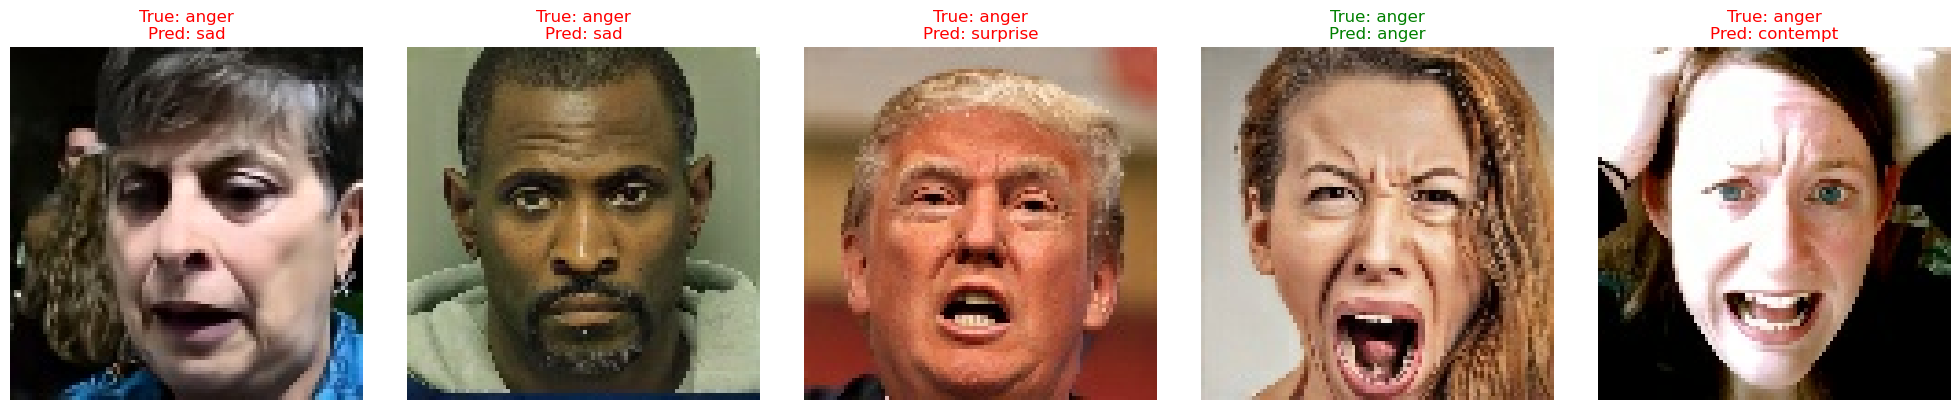

In [26]:
def predict_random_samples():

    # Get one batch
    images, labels = next(iter(test_dataset))

    # Random 5 images
    indices = np.random.choice(len(images), 5, replace=False)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    for i, idx in enumerate(indices):

        img = images[idx]

        # True label
        true_idx = labels[idx].numpy()
        true_label = CLASSES[true_idx]

        # Prediction
        pred_prob = model.predict(
            np.expand_dims(img, axis=0),
            verbose=0
        )

        pred_idx = np.argmax(pred_prob)
        pred_label = CLASSES[pred_idx]

        # Plot image
        axes[i].imshow(img.numpy().astype("uint8"))
        axes[i].axis("off")

        # Color
        color = "green" if true_label == pred_label else "red"

        axes[i].set_title(
            f"True: {true_label}\nPred: {pred_label}",
            color=color
        )

    plt.tight_layout()
    plt.show()

predict_random_samples()